# 2 Perceptrón: el problema XOR


**Perceptrón:** $\;$ versión determinista de regresión logística binaria
$$f(\boldsymbol{x};\boldsymbol{\theta})=\mathbb{I}(\boldsymbol{w}^t\boldsymbol{x}+b\geq 0)=H(\boldsymbol{w}^t\boldsymbol{x}+b)$$

**Libro Perceptrons:** $\;$ publicado en 1969 por Marvin Minsky y Seymour Papert, proporcionó numerosos ejemplos de problemas de clasificación que los perceptrones no resuelven

**Problema XOR:** $\;$ problema famoso del libro Perceptrons con datos 2d no linealmente separables

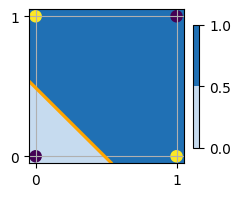

In [1]:
import numpy as np; import matplotlib.pyplot as plt
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([0, 1, 1, 0], dtype=int); # print(np.c_[X, y])
w = np.array([1, 1]); b = -0.5; P = lambda x: np.heaviside(w @ x + b, 0.0)
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2)); ax.grid()
ticks = [.0, 1.]; ax.set_xticks(ticks); ax.set_yticks(ticks)
R = np.linspace(-.05, 1.05, 50); x1, x2 = np.meshgrid(R, R)
XX = np.c_[np.ravel(x1), np.ravel(x2)]; yy = np.apply_along_axis(P, 1, XX)
ax.contour(x1, x2, yy.reshape(x1.shape), 1, colors='orange', linestyles='solid')
cp = ax.contourf(x1, x2, yy.reshape(x1.shape), 1, cmap='Blues')
plt.colorbar(cp, ax=ax, shrink=0.8); ax.scatter(*X.T, c=y, s=64);


<p style="page-break-after:always;"></p>


**Resolución de XOR con una composición de tres Perceptrones:** $\;$ dos **unidades ocultas,** $h_1$ y $h_2$, y la salida $y$

In [2]:
import graphviz; graphviz.Source('''digraph { rankdir=BT
yb [label="1"] yb -> y [label="-0.5"] h1 -> y [label="-1"] h2 -> y [label="+1"]
h1b [label="1"] h1b -> h1 [label="-1.5"] x1 -> h1 [label="+1"] x2 -> h1 [label="+1"]
h2b [label="1"] h2b -> h2 [label="-0.5"] x1 -> h2 [label="+1"] x2 -> h2 [label="+1"]
}''').render(filename='MLPXOR', format='svg');

<div align="center"><img src="MLPXOR.svg" width="300"/></div>

$$\normalsize\begin{array}{cccccccc}
x_1&x_2&\boldsymbol{w}_1^t\boldsymbol{x}+b_1&h_1&\boldsymbol{w}_2^t\boldsymbol{x}+b_2&h_2&\boldsymbol{w}_y^t\boldsymbol{h}+b_y&y\\\hline
0&0&-1.5&0&-0.5&0&-0.5&0\\
0&1&-0.5&0&+0.5&1&+0.5&1\\
1&0&-0.5&0&+0.5&1&+0.5&1\\
1&1&+0.5&1&+1.5&1&-0.5&0
\end{array}$$

$$\normalsize y=\neg h_1\wedge h_2=\neg(x_1\wedge x_2)\wedge(x_1\vee x_2)$$


<p style="page-break-after:always;"></p>


**Resolución de XOR con una composición de tres Perceptrones (cont.):** $\;$

<div align="center"><img src="MLPXOR.svg" width="300"/></div>

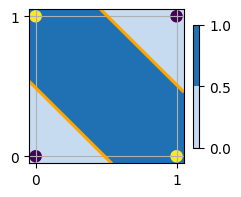

In [3]:
w1 = np.array([1, 1]); b1 = -1.5; w2 = np.array([1, 1]); b2 = -0.5; wy = np.array([-1, 1]); by = -0.5
P = lambda x, w, b: np.heaviside(w @ x + b, 0.0)
MLPXOR = lambda x: P(np.array([P(x, w1, b1), P(x, w2, b2)]), wy, by)
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2)); ax.grid()
ticks = [.0, 1.]; ax.set_xticks(ticks); ax.set_yticks(ticks)
R = np.linspace(-.05, 1.05, 50); x1, x2 = np.meshgrid(R, R)
XX = np.c_[np.ravel(x1), np.ravel(x2)]; yy = np.apply_along_axis(MLPXOR, 1, XX)
ax.contour(x1, x2, yy.reshape(x1.shape), 1, colors='orange', linestyles='solid')
cp = ax.contourf(x1, x2, yy.reshape(x1.shape), 1, cmap='Blues')
plt.colorbar(cp, ax=ax, shrink=0.8); ax.scatter(*X.T, c=y, s=64);


<p style="page-break-after:always;"></p>
